## 1 Preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.columns

In [4]:
df.duplicated().sum()

np.int64(1081)

In [12]:
df = df.drop_duplicates()

In [ ]:
df.columns

In [14]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [5]:
x["Time"]

0              0.0
1              0.0
2              1.0
3              1.0
4              2.0
            ...   
284802    172786.0
284803    172787.0
284804    172788.0
284805    172788.0
284806    172792.0
Name: Time, Length: 283726, dtype: float64

In [15]:
x["Time"] = (x["Time"] / 3600) % 24
x["Time"].astype(int)

0          0
1          0
2          0
3          0
4          0
          ..
284802    23
284803    23
284804    23
284805    23
284806    23
Name: Time, Length: 283726, dtype: int64

In [ ]:
x["Time"].describe()

In [ ]:
x.columns

In [ ]:
y

In [ ]:
x["Amount"]

In [16]:
scaler = RobustScaler()
x["Amount"] = scaler.fit_transform(x["Amount"].values.reshape(-1, 1))

In [ ]:
x["Amount"].describe()

In [ ]:
x.columns

## 2 EDA

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

# Thiết lập style chuẩn của seaborn cho đẹp và chuyên nghiệp
sns.set_theme(style="whitegrid")

# Định nghĩa màu sắc cố định (Normal: Xanh dương, Fraud: Đỏ)
colors = {0: "#1f77b4", 1: "#d62728"}
labels = {0: "Normal", 1: "Fraud"}

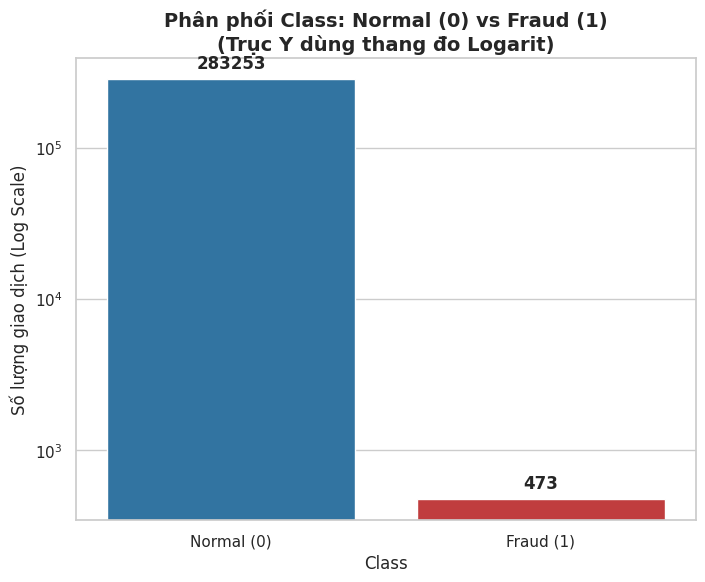

In [7]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Class', palette=colors, hue="Class", legend=False)

# Ép trục Y sang thang đo logarit để dễ nhìn thấy cột Class 1
ax.set_yscale('log')

plt.title('Phân phối Class: Normal (0) vs Fraud (1)\n(Trục Y dùng thang đo Logarit)', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Số lượng giao dịch (Log Scale)', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])

# Ghi chính xác con số lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.show()

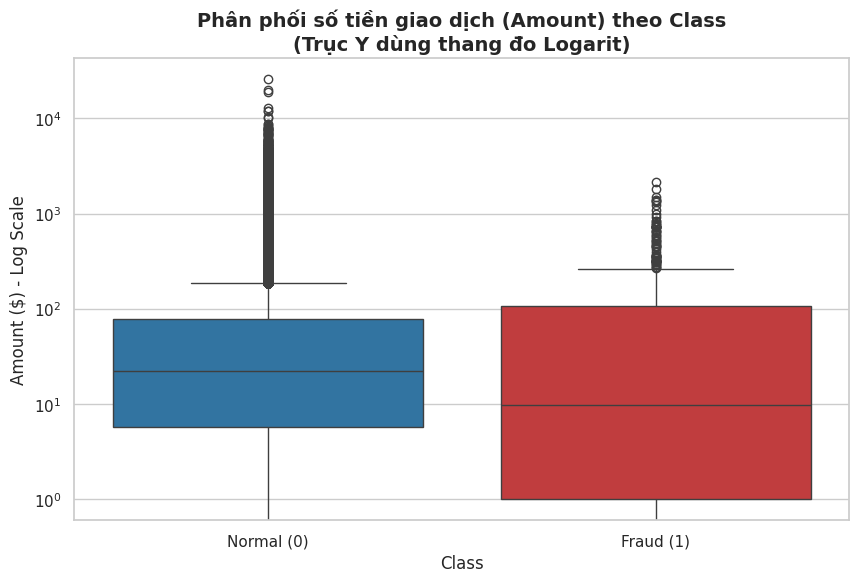

In [17]:
plt.figure(figsize=(10, 6))

# Vẽ Boxplot
ax = sns.boxplot(x="Class", y="Amount", data=df, palette=colors, hue="Class", legend=False)

# Vì giá trị tiền có giao dịch lên tới 25000$, ta cũng nên dùng Log Scale cho trục Y
ax.set_yscale('log')

plt.title('Phân phối số tiền giao dịch (Amount) theo Class\n(Trục Y dùng thang đo Logarit)', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Amount ($) - Log Scale', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])

plt.show()

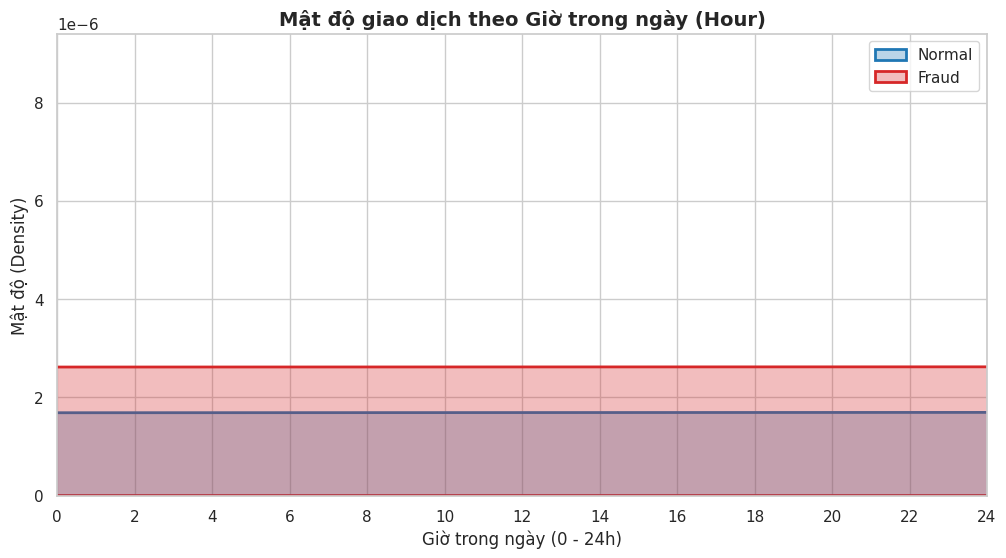

In [18]:
plt.figure(figsize=(12, 6))

# Vẽ đường cong mật độ cho Normal
sns.kdeplot(df[df['Class'] == 0]['Time'], label='Normal', color=colors[0], fill=True, alpha=0.3, linewidth=2)
# Vẽ đường cong mật độ cho Fraud
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud', color=colors[1], fill=True, alpha=0.3, linewidth=2)

plt.title('Mật độ giao dịch theo Giờ trong ngày (Hour)', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày (0 - 24h)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.xticks(np.arange(0, 25, 2)) # Hiển thị mốc thời gian chẵn: 0, 2, 4... 24
plt.xlim([0, 24])
plt.legend()

plt.show()

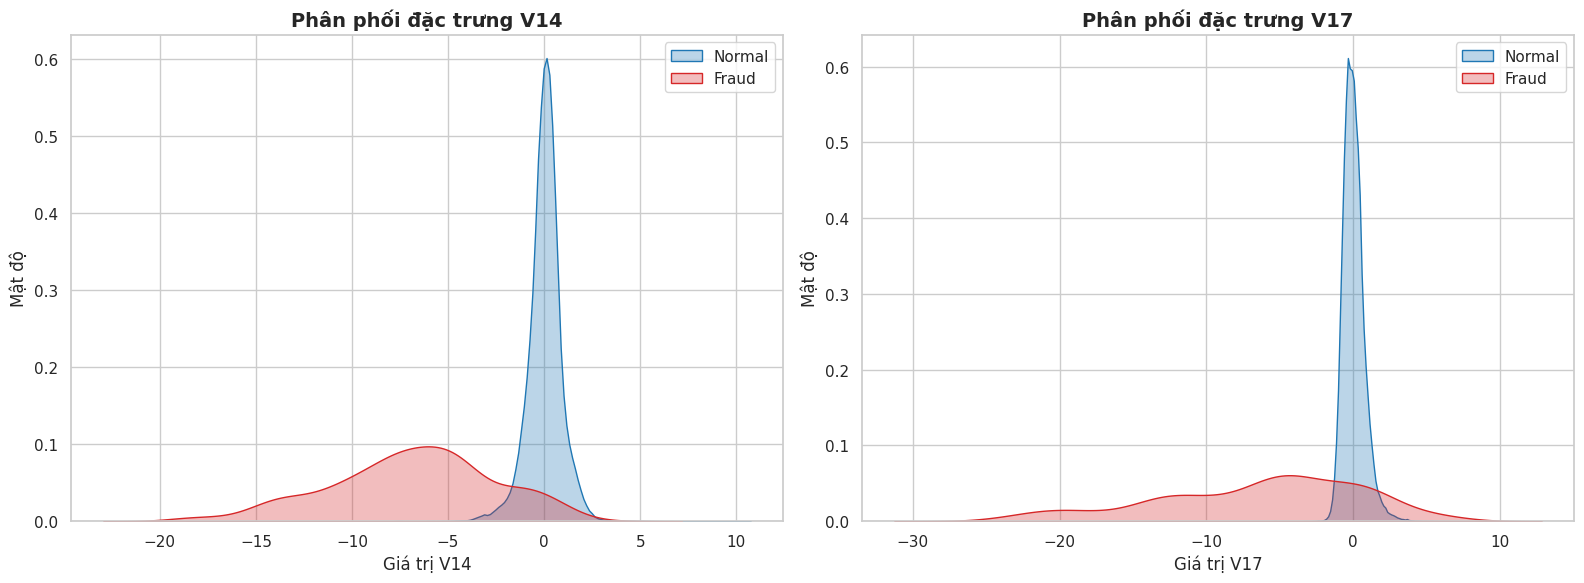

In [20]:
# Tạo 1 khung ảnh chứa 2 biểu đồ nhỏ (1 hàng, 2 cột)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: V14
sns.kdeplot(df[df['Class'] == 0]['V14'], ax=ax[0], label='Normal', color=colors[0], fill=True, alpha=0.3)
sns.kdeplot(df[df['Class'] == 1]['V14'], ax=ax[0], label='Fraud', color=colors[1], fill=True, alpha=0.3)
ax[0].set_title('Phân phối đặc trưng V14', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Giá trị V14', fontsize=12)
ax[0].set_ylabel('Mật độ', fontsize=12)
ax[0].legend()

# Biểu đồ 2: V17
sns.kdeplot(df[df['Class'] == 0]['V17'], ax=ax[1], label='Normal', color=colors[0], fill=True, alpha=0.3)
sns.kdeplot(df[df['Class'] == 1]['V17'], ax=ax[1], label='Fraud', color=colors[1], fill=True, alpha=0.3)
ax[1].set_title('Phân phối đặc trưng V17', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Giá trị V17', fontsize=12)
ax[1].set_ylabel('Mật độ', fontsize=12)
ax[1].legend()

plt.tight_layout() # Tránh việc 2 biểu đồ đè chữ lên nhau
plt.show()

## 3 Training

In [ ]:

# Chia tập dữ liệu, đảm bảo tỉ lệ Fraud/Normal được giữ nguyên (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
import xgboost as xgb

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

# Khai báo rõ ràng StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Tính toán scale_pos_weight dựa trên dữ liệu Train
# (Đếm số lượng nhãn 0 chia cho số lượng nhãn 1)
weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# 2. Khởi tạo model baseline
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=weight, # BẮT BUỘC PHẢI CÓ
    random_state=42
)

# 3. Định nghĩa không gian tìm kiếm (Search Space)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. Cấu hình RandomizedSearchCV
# Điểm ăn tiền: scoring='average_precision' (Tối ưu hóa PR-AUC thay vì Accuracy)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=15, # Chỉ thử 15 tổ hợp ngẫu nhiên (chỉnh lên 30 nếu máy mạnh)
    scoring='average_precision', 
    cv=skf, # Chia 3 fold
    verbose=2, # In log ra màn hình
    n_jobs=-1 # Dùng toàn bộ CPU cores
)

# 5. Huấn luyện
print("Đang tìm Hyperparameters tối ưu...")
random_search.fit(X_train, y_train)

# 6. Lấy model xịn nhất ra dùng
best_model = random_search.best_estimator_
print(f"Tham số tốt nhất: {random_search.best_params_}")

# 7. Dự đoán
predictions = best_model.predict(X_test)

Đang tìm Hyperparameters tối ưu...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tham số tốt nhất: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.78      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746